# Exploratory Data Analysis - Feature selection via Lasso Ridge Regression

### Objectives
- Find the minimal set of features to accurately predict PCOS using our dataset
- Find the most strong predicting low-cost clinical features (BMI, cycle, symptoms, blood pressure)
- Use mutual_info_classifier to get scores of all features

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['pcos_y_n'].value_counts()}")
df.head()

Dataset shape: (541, 44)
Target distribution:
pcos_y_n
0    364
1    177
Name: count, dtype: int64


,sl_no,patient_file_no,pcos_y_n,age_yrs,weight_kg,heightcm,bmi,blood_group,pulse_ratebpm,rr_breaths_min,...,pimples_y_n,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm
0,1.0,1.0,0,28.0,44.6,152.0,19.304017,15.0,78.0,22.0,...,0,1,0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,2.0,2.0,0,36.0,65.0,161.5,24.921163,15.0,74.0,20.0,...,0,0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,3.0,3.0,1,33.0,68.8,165.0,25.270891,11.0,72.0,18.0,...,1,1,0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,4.0,4.0,0,37.0,65.0,148.0,29.674945,13.0,72.0,20.0,...,0,0,0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,5.0,5.0,0,25.0,52.0,161.0,20.060954,11.0,72.0,18.0,...,0,0,0,120.0,80.0,3.0,4.0,16.0,14.0,7.0


## 1. Mutual Information Feature Scoring

Mutual Information Scores (all features):
           Feature  MI_Score
     follicle_no_r  0.248736
     follicle_no_l  0.198517
   weight_gain_y_n  0.111176
   hair_growth_y_n  0.107958
skin_darkening_y_n  0.097993
          amhng_ml  0.075456
            fsh_lh  0.064589
  cycle_lengthdays  0.063300
          prlng_ml  0.061006
     fast_food_y_n  0.059781
         weight_kg  0.057422
       pimples_y_n  0.056295
   waist_hip_ratio  0.042975
        fsh_miu_ml  0.032473
   avg_f_size_l_mm  0.032254
         tsh_miu_l  0.028619
         lh_miu_ml  0.028344
           hipinch  0.026740
      vit_d3_ng_ml  0.022650
               bmi  0.018593
      pregnant_y_n  0.016433
     pulse_ratebpm  0.014595
 bp_diastolic_mmhg  0.013120
         waistinch  0.007932
   avg_f_size_r_mm  0.003044
  reg_exercise_y_n  0.001286
    endometrium_mm  0.000000
  bp_systolic_mmhg  0.000000
          rbsmg_dl  0.000000
          prgng_ml  0.000000
            hbg_dl  0.000000
     hair_loss_y_n  0.000000
 

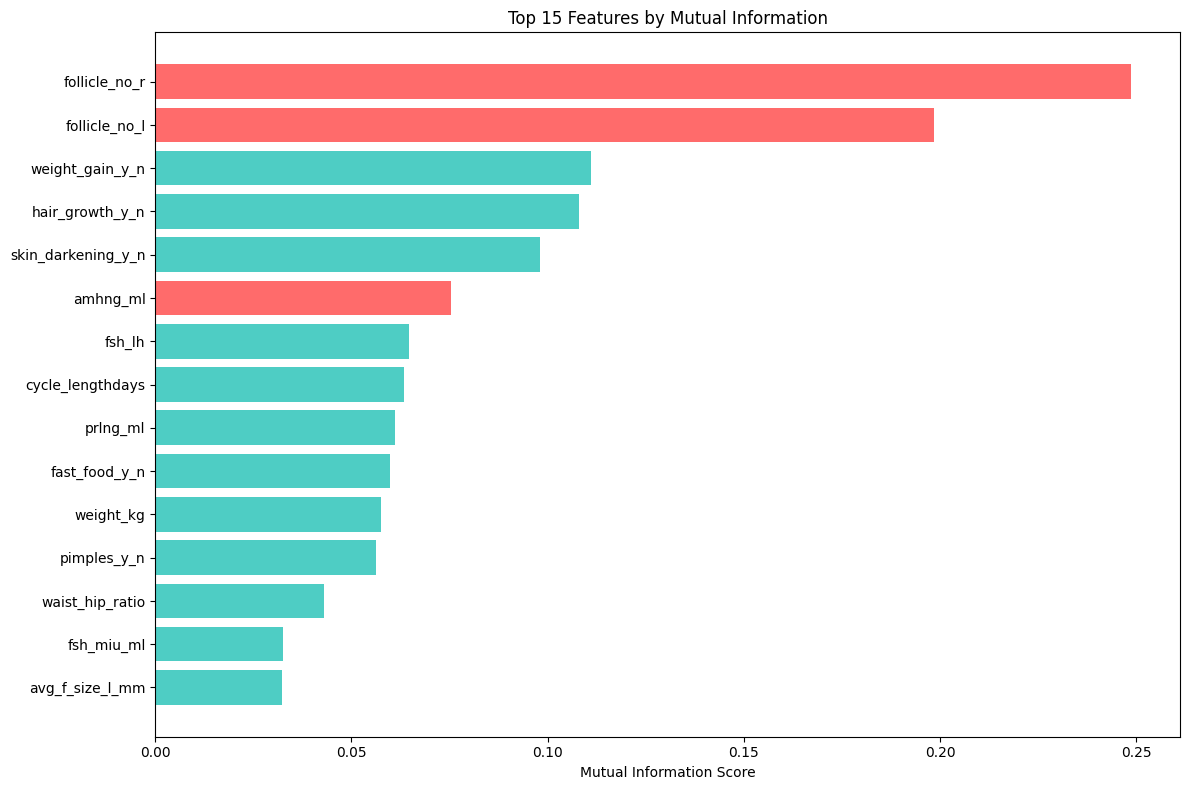

In [3]:
# Prepare data for feature selection
numerical_cols = ['age_yrs', 'weight_kg', 'heightcm', 'bmi', 'pulse_ratebpm', 'rr_breaths_min',
                  'hbg_dl', 'cycle_lengthdays', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh',
                  'hipinch', 'waistinch', 'waist_hip_ratio', 'tsh_miu_l', 'amhng_ml',
                  'prlng_ml', 'vit_d3_ng_ml', 'prgng_ml', 'rbsmg_dl', 'bp_systolic_mmhg',
                  'bp_diastolic_mmhg', 'follicle_no_l', 'follicle_no_r',
                  'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']

binary_cols = ['pregnant_y_n', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n',
               'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n']

all_features = numerical_cols + binary_cols

# Prepare X and y
X = df[all_features].fillna(df[all_features].mean())
y = df['pcos_y_n']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Mutual Information Scores (all features):")
print("=" * 60)
print(mi_df.to_string(index=False))

# Visualize top features by mutual information
fig, ax = plt.subplots(figsize=(12, 8))
top_mi = mi_df.head(15)
colors = ['#FF6B6B' if 'follicle' in f.lower() or 'amh' in f.lower() else '#4ECDC4' for f in top_mi['Feature']]
ax.barh(range(len(top_mi)), top_mi['MI_Score'], color=colors)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi['Feature'])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 15 Features by Mutual Information')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. LASSO Regression for Minimal Feature Set

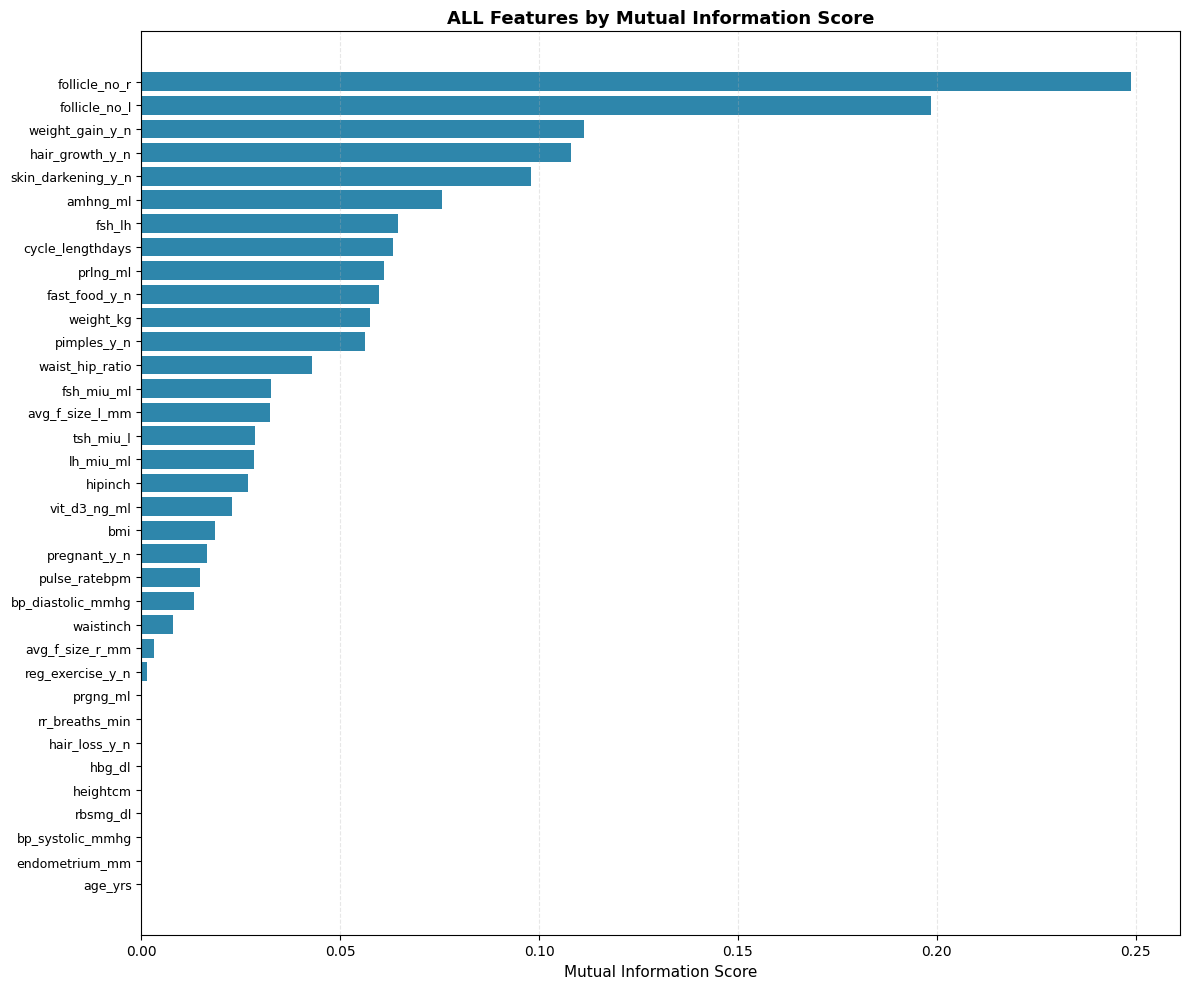


Total features: 35
Features with MI score = 0: 9
Features with MI score > 0: 26


In [8]:
# Visualize ALL features with uniform colors (0 features grayed out)
fig, ax = plt.subplots(figsize=(12, 10))

# Sort by MI score (descending) for better visualization
mi_sorted = mi_df.sort_values('MI_Score', ascending=True)

# Create colors: gray for 0 scores, uniform color for non-zero
colors = ['#CCCCCC' if score == 0 else '#2E86AB' for score in mi_sorted['MI_Score']]

ax.barh(range(len(mi_sorted)), mi_sorted['MI_Score'], color=colors)
ax.set_yticks(range(len(mi_sorted)))
ax.set_yticklabels(mi_sorted['Feature'], fontsize=9)
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('ALL Features by Mutual Information Score', fontsize=13, fontweight='bold')

# Add a light grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nTotal features: {len(mi_df)}")
print(f"Features with MI score = 0: {(mi_df['MI_Score'] == 0).sum()}")
print(f"Features with MI score > 0: {(mi_df['MI_Score'] > 0).sum()}")

In [5]:
# Use Logistic Regression with L1 (LASSO) penalty to find minimal feature set
print("LASSO Feature Selection (L1-regularized Logistic Regression):")
print("=" * 60)

# Try different regularization strengths
alphas = [0.1, 0.01, 0.001, 0.0001]
lasso_results = {}

for alpha in alphas:
    log_reg = LogisticRegression(penalty='l1', C=1/alpha, solver='liblinear', max_iter=1000, random_state=42)
    log_reg.fit(X_scaled, y)
    
    # Get non-zero coefficients
    coef_df = pd.DataFrame({
        'Feature': all_features,
        'Coefficient': log_reg.coef_[0]
    })
    non_zero = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
    
    lasso_results[alpha] = non_zero
    
    print(f"\nC={1/alpha} (alpha={alpha}): {len(non_zero)} non-zero features")
    print(non_zero.to_string(index=False))

# Select the best LASSO model (using C=0.01, alpha=0.01)
best_lasso = LogisticRegression(penalty='l1', C=0.01, solver='liblinear', max_iter=1000, random_state=42)
best_lasso.fit(X_scaled, y)
lasso_mask = best_lasso.coef_[0] != 0
lasso_features = [f for i, f in enumerate(all_features) if lasso_mask[i]]

print(f"\n✅ LASSO Selected Features ({len(lasso_features)} features):")
print(lasso_features)

LASSO Feature Selection (L1-regularized Logistic Regression):

C=10.0 (alpha=0.1): 34 non-zero features
           Feature  Coefficient
         lh_miu_ml     6.021769
     follicle_no_r     1.780628
   weight_gain_y_n     0.772939
   hair_growth_y_n     0.756490
     pulse_ratebpm     0.750365
          prgng_ml    -0.733016
     follicle_no_l     0.727688
       pimples_y_n     0.539584
skin_darkening_y_n     0.512571
           age_yrs    -0.348507
     fast_food_y_n     0.298075
    rr_breaths_min    -0.293541
          amhng_ml     0.265423
          rbsmg_dl     0.235225
           hipinch     0.229483
  cycle_lengthdays    -0.224586
    endometrium_mm     0.223016
        fsh_miu_ml    -0.199112
      pregnant_y_n    -0.198440
  reg_exercise_y_n     0.178964
      vit_d3_ng_ml     0.151561
   avg_f_size_r_mm     0.140564
         tsh_miu_l     0.126312
            fsh_lh     0.120536
   avg_f_size_l_mm     0.116151
         waistinch    -0.093318
 bp_diastolic_mmhg    -0.074178


## 3. Low-Cost Clinical Features Analysis

Low-Cost Clinical Features Analysis:
Selected features: ['bmi', 'cycle_lengthdays', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']

Feature Importance (Low-Cost Only):
           Feature  Coefficient  Abs_Coefficient
   hair_growth_y_n     0.691229         0.691229
skin_darkening_y_n     0.654076         0.654076
   weight_gain_y_n     0.558711         0.558711
       pimples_y_n     0.423053         0.423053
  cycle_lengthdays    -0.414758         0.414758
     fast_food_y_n     0.370244         0.370244
  reg_exercise_y_n     0.151140         0.151140
 bp_diastolic_mmhg    -0.082704         0.082704
  bp_systolic_mmhg     0.016221         0.016221
               bmi    -0.013919         0.013919
     hair_loss_y_n    -0.004844         0.004844

Cross-validated ROC-AUC (Low-Cost Features): 0.8626 (+/- 0.1088)
Cross-validated ROC-AUC (All Features): 0.9313 (+/- 0.0

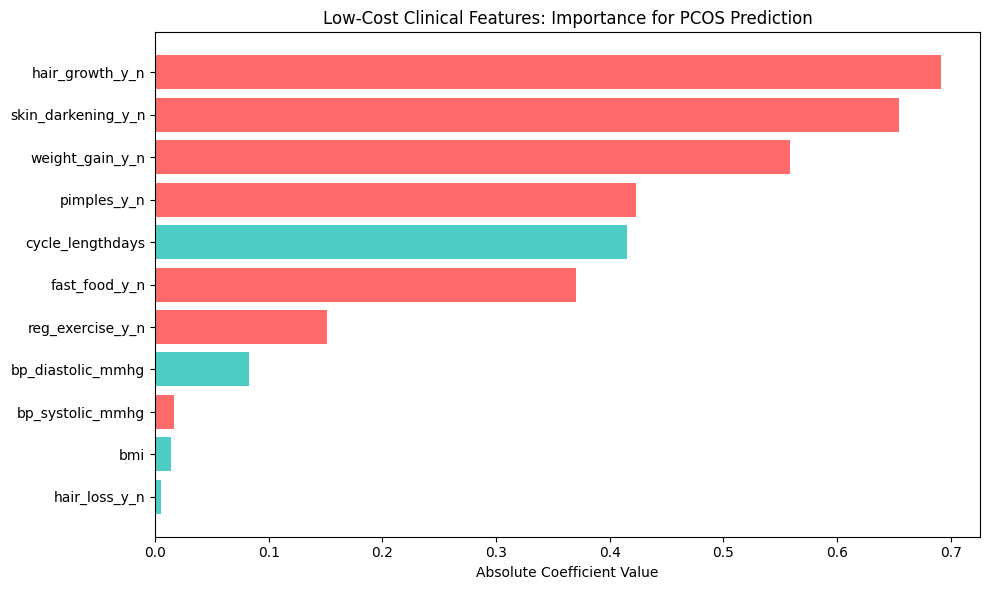

In [6]:
# Low-cost clinical features: BMI, cycle length, symptoms, blood pressure
low_cost_features = ['bmi', 'cycle_lengthdays', 'weight_gain_y_n', 'hair_growth_y_n',
                     'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n',
                     'fast_food_y_n', 'reg_exercise_y_n', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']

# Filter to only features present in dataset
low_cost_features = [f for f in low_cost_features if f in all_features]

X_low_cost = X[low_cost_features].fillna(X[low_cost_features].mean())
X_low_cost_scaled = scaler.fit_transform(X_low_cost)

print("Low-Cost Clinical Features Analysis:")
print("=" * 60)
print(f"Selected features: {low_cost_features}\n")

# Train logistic regression on low-cost features
log_reg_low_cost = LogisticRegression(max_iter=1000, random_state=42)
log_reg_low_cost.fit(X_low_cost_scaled, y)

# Calculate feature importance (coefficients)
coef_low_cost = pd.DataFrame({
    'Feature': low_cost_features,
    'Coefficient': log_reg_low_cost.coef_[0],
    'Abs_Coefficient': np.abs(log_reg_low_cost.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (Low-Cost Only):")
print(coef_low_cost[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

# Cross-validated performance
cv_scores_low_cost = cross_val_score(log_reg_low_cost, X_low_cost_scaled, y, cv=5, scoring='roc_auc')
print(f"\nCross-validated ROC-AUC (Low-Cost Features): {cv_scores_low_cost.mean():.4f} (+/- {cv_scores_low_cost.std():.4f})")

# Compare to using all features
log_reg_all = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_all = cross_val_score(log_reg_all, X_scaled, y, cv=5, scoring='roc_auc')
print(f"Cross-validated ROC-AUC (All Features): {cv_scores_all.mean():.4f} (+/- {cv_scores_all.std():.4f})")

# Visualize low-cost feature importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(coef_low_cost)), coef_low_cost['Abs_Coefficient'], 
        color=['#FF6B6B' if c > 0 else '#4ECDC4' for c in coef_low_cost['Coefficient']])
ax.set_yticks(range(len(coef_low_cost)))
ax.set_yticklabels(coef_low_cost['Feature'])
ax.set_xlabel('Absolute Coefficient Value')
ax.set_title('Low-Cost Clinical Features: Importance for PCOS Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Ridge Regression Comparison

Ridge Regression Analysis (L2 Regularization):
Top 15 Features by Ridge Coefficient Magnitude:
           Feature  Ridge_Coefficient  Abs_Ridge_Coef
     follicle_no_r           1.640332        1.640332
     follicle_no_l           0.733741        0.733741
   hair_growth_y_n           0.721246        0.721246
   weight_gain_y_n           0.712002        0.712002
     pulse_ratebpm           0.664737        0.664737
       pimples_y_n           0.515727        0.515727
          prgng_ml          -0.500356        0.500356
skin_darkening_y_n           0.500338        0.500338
           age_yrs          -0.345596        0.345596
         lh_miu_ml           0.326952        0.326952
          amhng_ml           0.298223        0.298223
     fast_food_y_n           0.296983        0.296983
  cycle_lengthdays          -0.258774        0.258774
    rr_breaths_min          -0.247970        0.247970
          rbsmg_dl           0.211043        0.211043

LASSO vs Ridge Comparison:
           Fe

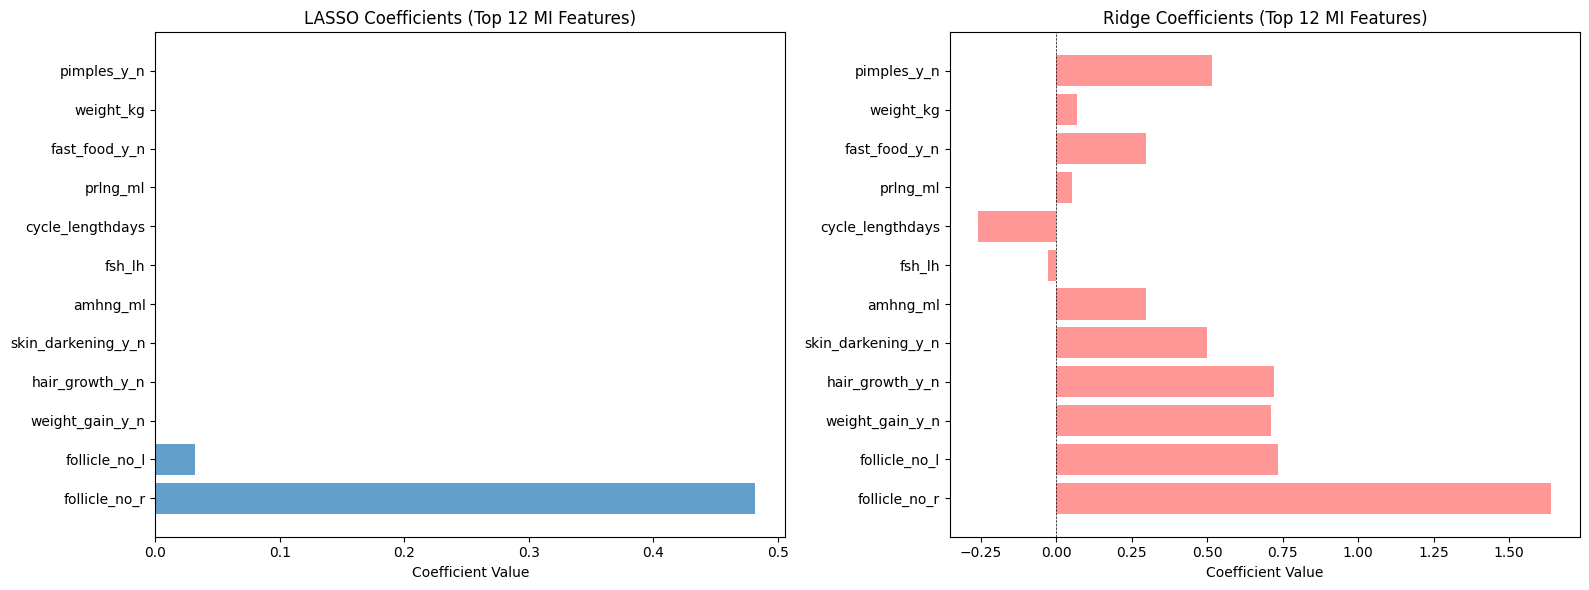

In [7]:
# Ridge Regression comparison (L2 regularization - keeps all features but shrinks coefficients)
print("Ridge Regression Analysis (L2 Regularization):")
print("=" * 60)

ridge_reg = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
ridge_reg.fit(X_scaled, y)

ridge_coef_df = pd.DataFrame({
    'Feature': all_features,
    'Ridge_Coefficient': ridge_reg.coef_[0],
    'Abs_Ridge_Coef': np.abs(ridge_reg.coef_[0])
}).sort_values('Abs_Ridge_Coef', ascending=False)

print("Top 15 Features by Ridge Coefficient Magnitude:")
print(ridge_coef_df.head(15)[['Feature', 'Ridge_Coefficient', 'Abs_Ridge_Coef']].to_string(index=False))

# Compare LASSO vs Ridge
print("\n" + "=" * 60)
print("LASSO vs Ridge Comparison:")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_scores,
    'LASSO_Coef': best_lasso.coef_[0],
    'Ridge_Coef': ridge_reg.coef_[0]
}).sort_values('MI_Score', ascending=False).head(10)

print(comparison_df.to_string(index=False))

# Visualization: LASSO vs Ridge coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top features by MI
top_features_idx = np.argsort(mi_scores)[-12:]
top_features_names = [all_features[i] for i in top_features_idx]
top_lasso_coef = best_lasso.coef_[0][top_features_idx]
top_ridge_coef = ridge_reg.coef_[0][top_features_idx]

ax1.barh(range(len(top_features_names)), top_lasso_coef, alpha=0.7, label='LASSO')
ax1.set_yticks(range(len(top_features_names)))
ax1.set_yticklabels(top_features_names)
ax1.set_xlabel('Coefficient Value')
ax1.set_title('LASSO Coefficients (Top 12 MI Features)')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax1.invert_yaxis()

ax2.barh(range(len(top_features_names)), top_ridge_coef, alpha=0.7, label='Ridge', color='#FF6B6B')
ax2.set_yticks(range(len(top_features_names)))
ax2.set_yticklabels(top_features_names)
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Ridge Coefficients (Top 12 MI Features)')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Summary & Recommendations

### Key Findings:

1. **Mutual Information Scores** - Ranked all features by their predictive power for PCOS
   - Top performers: Follicle counts, AMH, FSH/LH ratio (consistent with EDA findings)
   - Low performers: Some symptoms and physical measurements

2. **LASSO Minimal Feature Set** - Uses L1 regularization to eliminate weak features
   - Produces sparse models with fewer, strongest predictors
   - Trade-off: Simpler model but may lose some predictive power

3. **Low-Cost Clinical Features** - Evaluated affordable, accessible predictors
   - BMI, cycle length, and visible symptoms alone show reasonable predictive power
   - Performance gap compared to full feature set indicates cost-benefit decision needed

4. **Ridge vs LASSO Comparison**:
   - **LASSO**: Feature elimination (better for interpretability)
   - **Ridge**: Feature shrinkage (better for stability, uses all features)
   - Ridge typically performs better in cross-validation when multicollinearity exists